In [ ]:
# Install required libraries
!pip install rasterio matplotlib numpy

In [2]:
import os
import glob
import rasterio
import matplotlib.pyplot as plt
import numpy as np

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [10]:
# GANTI path ini dengan lokasi FOLDER tempat file EMIT berada
FOLDER_PATH = '/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping/data/emit/masked'

# Mencari semua file berakhiran .tif di dalam folder tersebut
search_pattern = os.path.join(FOLDER_PATH, '*.tif')
tif_files = sorted(glob.glob(search_pattern))

if not tif_files:
    print(f"[ERROR] Tidak ada file .tif yang ditemukan di {FOLDER_PATH}")
else:
    print(f"Ditemukan {len(tif_files)} file EMIT. Memulai inspeksi...\n")

Ditemukan 6 file EMIT. Memulai inspeksi...



In [11]:
print("=== RINGKASAN METADATA BATCH ===")
for i, file_path in enumerate(tif_files, start=1):
    filename = os.path.basename(file_path)
    with rasterio.open(file_path) as src:
        print(f"{i}. {filename}")
        print(f"   -> Dimensi : {src.width} x {src.height} piksel")
        print(f"   -> Bands   : {src.count}")
        print(f"   -> CRS     : {src.crs}\n")

=== RINGKASAN METADATA BATCH ===
1. aus_a_EMIT_L2A_RFL_001_20250703T235254_cropped.tif
   -> Dimensi : 475 x 334 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326

2. aus_b_EMIT_L2A_RFL_001_20250503T235856_cropped.tif
   -> Dimensi : 475 x 334 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326

3. belize_a_EMIT_L2A_RFL_001_20251020_cropped.tif
   -> Dimensi : 382 x 337 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326

4. belize_b_EMIT_L2A_RFL_001_20250824_cropped.tif
   -> Dimensi : 402 x 337 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326

5. elsavador_EMIT_L2A_RFL_001_20251128T161402_cropped.tif
   -> Dimensi : 403 x 329 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326

6. india_EMIT_L2A_RFL_001_20250201_cropped.tif
   -> Dimensi : 255 x 364 piksel
   -> Bands   : 579
   -> CRS     : EPSG:4326



Mengekstrak profil spektral untuk visualisasi panel ganda...


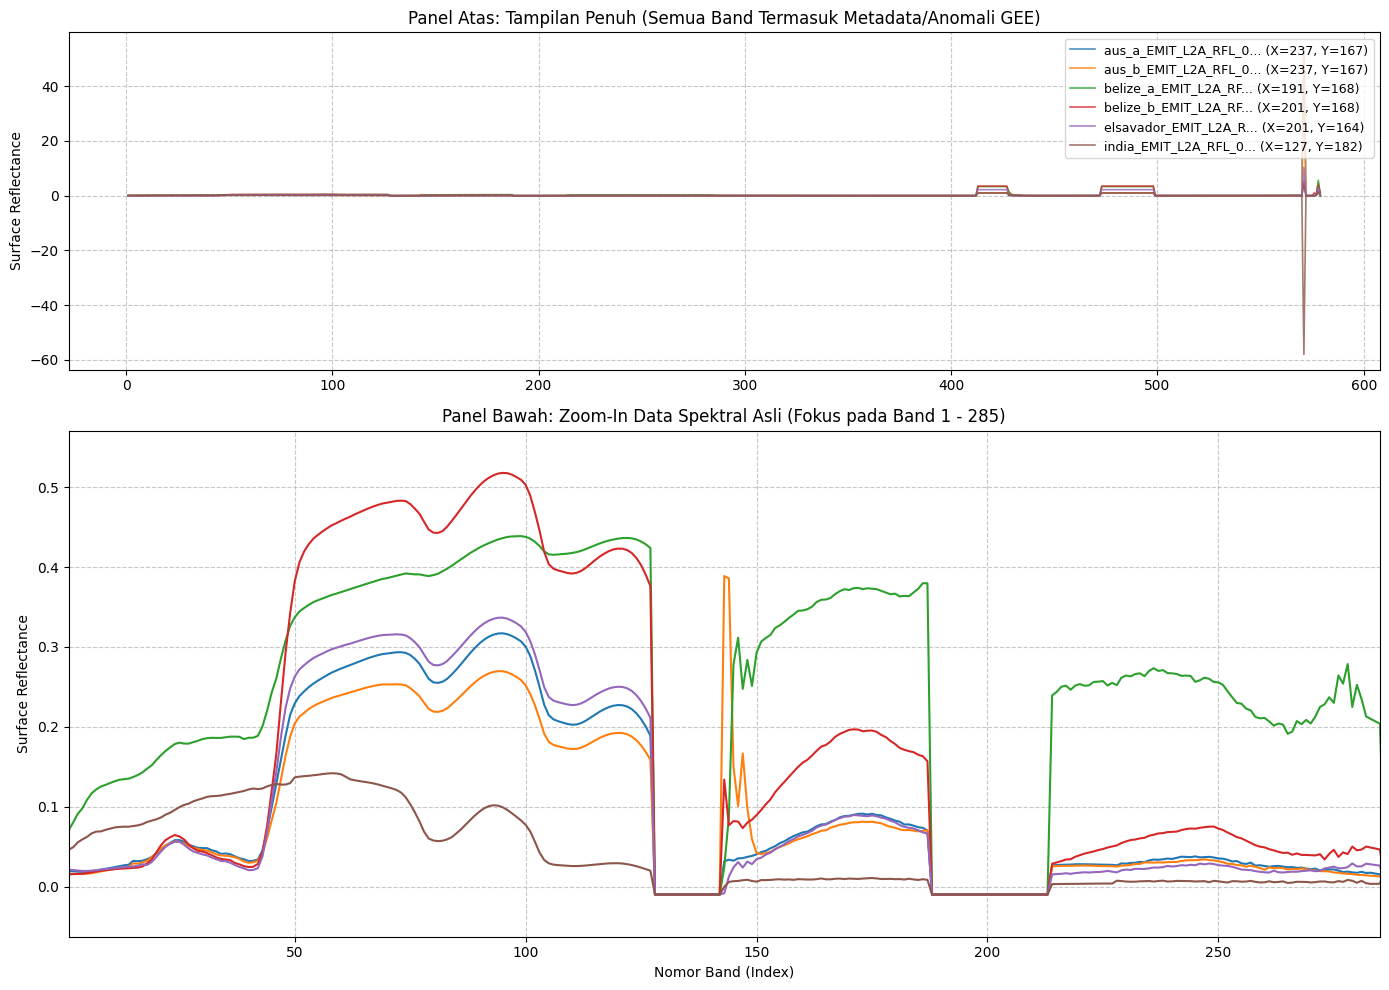

In [15]:
# Membuat figure dengan 2 baris (panel atas dan bawah)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.5]})
colors = plt.cm.tab10.colors

print("Mengekstrak profil spektral untuk visualisasi panel ganda...")

# Variabel untuk melacak batas atas/bawah agar zoom sumbu Y pas di panel bawah
max_y_zoom = -np.inf
min_y_zoom = np.inf

for i, file_path in enumerate(tif_files):
    filename = os.path.basename(file_path)

    with rasterio.open(file_path) as src:
        # Ambil titik tengah dari masing-masing citra
        row_y = src.height // 2
        col_x = src.width // 2

        # Ekstrak nilai spektral pada koordinat tersebut
        spatial_coords = [(src.xy(row_y, col_x))]
        spectral_profile = list(src.sample(spatial_coords))[0]

        # Bersihkan nilai NoData
        if src.nodata is not None:
            spectral_profile = np.where(spectral_profile == src.nodata, np.nan, spectral_profile)
        else:
            spectral_profile = np.where(spectral_profile < -100, np.nan, spectral_profile.astype('float32'))

        # Buat sumbu X
        bands_x = np.arange(1, src.count + 1)

        c = colors[i % len(colors)] # Rotasi warna
        # Menggunakan nama file sebagai label (dipotong sedikit agar tidak terlalu panjang di legend)
        label_name = f"{filename[:20]}... (X={col_x}, Y={row_y})"

        # ---------------------------------------------------------
        # PLOT 1: Panel Atas (Tampilan Penuh)
        # ---------------------------------------------------------
        ax1.plot(bands_x, spectral_profile, label=label_name, color=c, linewidth=1.2, alpha=0.8)

        # ---------------------------------------------------------
        # PLOT 2: Panel Bawah (Zoom Fokus Band 1-285)
        # ---------------------------------------------------------
        ax2.plot(bands_x, spectral_profile, color=c, linewidth=1.5)

        # Kalkulasi batas Y hanya dari 285 band pertama (data reflectance asli EMIT)
        valid_reflectance = spectral_profile[:285]
        valid_reflectance = valid_reflectance[~np.isnan(valid_reflectance)]
        if len(valid_reflectance) > 0:
            max_y_zoom = max(max_y_zoom, np.nanmax(valid_reflectance))
            min_y_zoom = min(min_y_zoom, np.nanmin(valid_reflectance))

# --- Formatting Panel Atas (Default/Full View) ---
ax1.set_title('Panel Atas: Tampilan Penuh (Semua Band Termasuk Metadata/Anomali GEE)')
# Gunakan "Surface Reflectance" (Baku dan tanpa satuan fisis)
ax1.set_ylabel('Surface Reflectance')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right', fontsize=9)

# --- Formatting Panel Bawah (Zoomed-In View) ---
ax2.set_title('Panel Bawah: Zoom-In Data Spektral Asli (Fokus pada Band 1 - 285)')
ax2.set_xlabel('Nomor Band (Index)')
# Gunakan "Surface Reflectance" (Baku dan tanpa satuan fisis)
ax2.set_ylabel('Surface Reflectance')

# Pangkas sumbu X secara paksa hanya sampai band ke-285
ax2.set_xlim(1, 285)

# Sesuaikan sumbu Y secara otomatis berdasarkan nilai asli dengan margin 10%
if max_y_zoom != -np.inf:
    margin = (max_y_zoom - min_y_zoom) * 0.1
    ax2.set_ylim(min_y_zoom - margin, max_y_zoom + margin)

ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

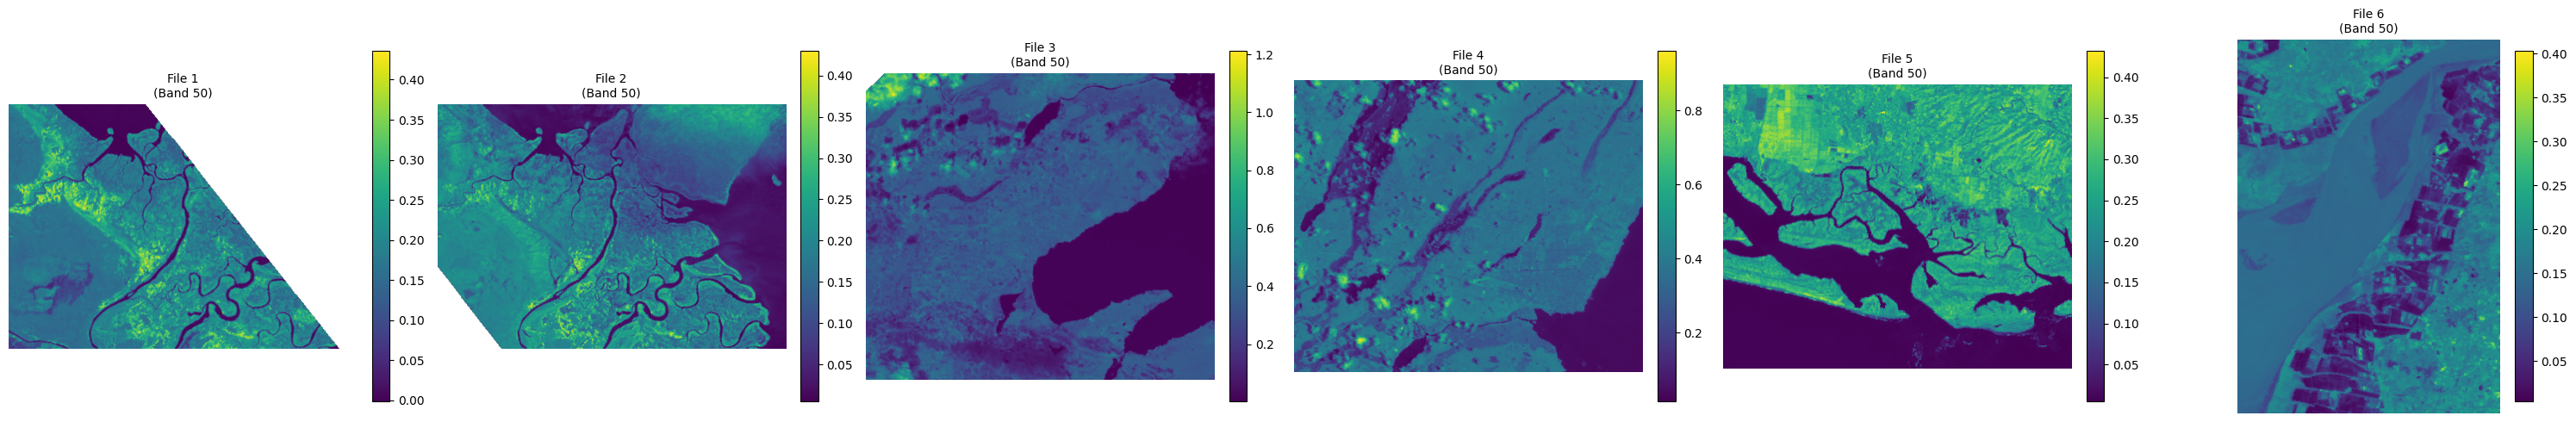

In [7]:
# Ubah angka 4 menjadi 6 (atau gunakan len(tif_files) untuk menggambar semuanya)
max_files_to_plot = min(len(tif_files), 6)

# Saya sarankan untuk mengubah tata letaknya menjadi 2 baris x 3 kolom agar peta tidak terlalu memanjang.
# Namun jika ingin tetap 1 baris memanjang, gunakan script di bawah ini:
fig, axes = plt.subplots(1, max_files_to_plot, figsize=(5 * max_files_to_plot, 5))

# Jika hanya ada 1 file, matplotlib tidak membuat array axes, jadi kita bungkus ke list
if max_files_to_plot == 1:
    axes = [axes]

for i in range(max_files_to_plot):
    file_path = tif_files[i]
    filename = os.path.basename(file_path)

    with rasterio.open(file_path) as src:
        # Baca band 50
        img_2d = src.read(50)

        # Bersihkan Nodata
        if src.nodata is not None:
            img_2d = np.where(img_2d == src.nodata, np.nan, img_2d)
        else:
            img_2d = np.where(img_2d < -100, np.nan, img_2d.astype('float32'))

        # Plot di subplot yang sesuai
        ax = axes[i]
        im = ax.imshow(img_2d, cmap='viridis')
        ax.set_title(f"File {i+1}\n(Band 50)", fontsize=10)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [14]:
import os
import math
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Batasi jumlah file maksimal yang akan dirender
max_files_to_plot = min(len(tif_files), 6)

# Setup Grid Layout: 3 Kolom, Baris menyesuaikan jumlah file (2 baris untuk 6 file)
cols = 3
rows = math.ceil(max_files_to_plot / cols)

# Membuat kanvas (Figure) dan array axes (Subplots)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))

# Ratakan array axes menjadi 1D agar mudah diakses di dalam loop
# (Jika axes hanya 1D misal 1x3, kita tetap ratakan agar seragam)
axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

# Tentukan kombinasi Band untuk RGB (True Color EMIT)
R_BAND = 54
G_BAND = 35
B_BAND = 19

print("Menyiapkan visualisasi komposit RGB...")

for i in range(max_files_to_plot):
    file_path = tif_files[i]
    filename = os.path.basename(file_path)

    with rasterio.open(file_path) as src:
        # 1. Baca ketiga band RGB
        img_r = src.read(R_BAND)
        img_g = src.read(G_BAND)
        img_b = src.read(B_BAND)

        # 2. Tumpuk menjadi matriks 3D dan ubah urutan dimensinya
        # Rasterio membaca (Band, Y, X), sedangkan matplotlib butuh (Y, X, Band)
        img_rgb = np.stack([img_r, img_g, img_b])
        img_rgb = np.transpose(img_rgb, (1, 2, 0))

        # 3. Bersihkan NoData
        if src.nodata is not None:
            mask = (img_rgb == src.nodata)
        else:
            mask = (img_rgb < -100)
        img_rgb = np.where(mask, np.nan, img_rgb.astype('float32'))

        # 4. Normalisasi Kontras (Contrast Stretch 2% - 98%)
        # Agar warna RGB satelit tidak terlihat gelap
        p2, p98 = np.nanpercentile(img_rgb, (2, 98))
        img_rgb_stretched = np.clip((img_rgb - p2) / (p98 - p2), 0, 1)

        # 5. Plot ke subplot yang sesuai
        ax = axes[i]
        ax.imshow(img_rgb_stretched)

        # Gunakan nama file murni sebagai judul
        ax.set_title(filename, fontsize=9, pad=10, wrap=True)
        ax.axis('off')

# Matikan sisa frame subplot yang kosong (misal jika total file hanya 4 atau 5)
for j in range(max_files_to_plot, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.